In [5]:
import json
import re
import glob
import matplotlib.pyplot as plt

base_dir = "/data/250010186/SFT_model/homework"

models = {
    "full": "Qwen4B_SFT_baseline",
    "0-1-2": "Qwen4B_SFT_layers_0_1_2",
    "16-17-18": "Qwen4B_SFT_layers_16_17_18",
    "33-34-35": "Qwen4B_SFT_layers_33_34_35",
}

In [6]:
# 提取最终 loss（取最后一次记录的 Loss）
losses = {}
for label, folder in models.items():
    log_path = f"{base_dir}/{folder}/log.log"
    with open(log_path, "r") as f:
        text = f.read()
    matches = re.findall(r"Loss: ([\d.]+)", text)
    losses[label] = float(matches[-1])

losses

{'full': 0.5414830684661865,
 '0-1-2': 1.0231093406677245,
 '16-17-18': 0.9801197052001953,
 '33-34-35': 1.0153520584106446}

In [7]:
# 提取 ifeval 的 prompt_level_strict_acc,none
ifeval_scores = {}
for label, folder in models.items():
    pattern = f"{base_dir}/{folder}/finetune/metrics/ifeval_lm_eval/*/results_*.json"
    result_path = sorted(glob.glob(pattern))[-1]
    with open(result_path, "r") as f:
        data = json.load(f)
    ifeval_scores[label] = data["results"]["ifeval"]["prompt_level_strict_acc,none"]

ifeval_scores

{'full': 0.5933456561922366,
 '0-1-2': 0.36968576709796674,
 '16-17-18': 0.5693160813308688,
 '33-34-35': 0.3456561922365989}

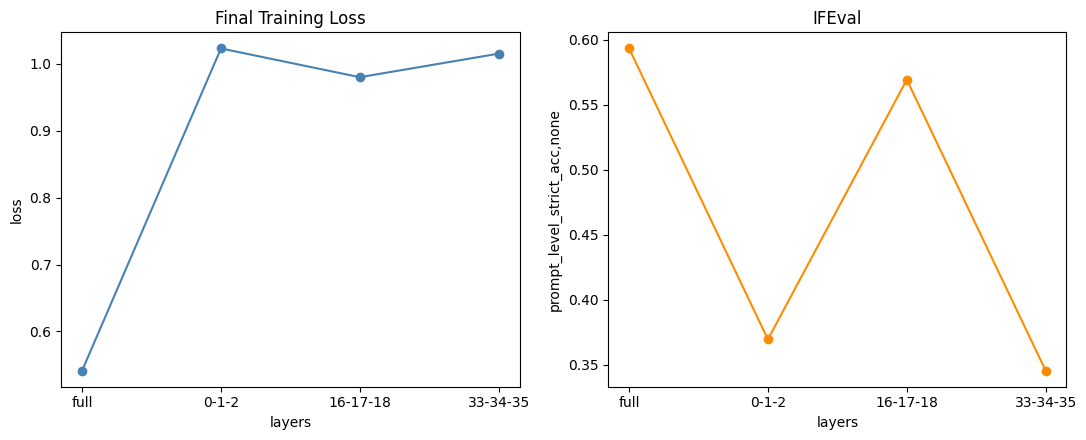

In [8]:
labels = list(models.keys())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(labels, [losses[l] for l in labels], marker="o", color="steelblue")
axes[0].set_xlabel("layers")
axes[0].set_ylabel("loss")
axes[0].set_title("Final Training Loss")

axes[1].plot(labels, [ifeval_scores[l] for l in labels], marker="o", color="darkorange")
axes[1].set_xlabel("layers")
axes[1].set_ylabel("prompt_level_strict_acc,none")
axes[1].set_title("IFEval")

plt.tight_layout()
plt.savefig("homework_results.png", dpi=150)
plt.show()